# Evaluación del Modelo de Clasificación: Interpretación Clínica y Serialización

# Introducción

Tras concluir la fase de *benchmarking*, donde se evaluaron múltiples arquitecturas bajo un esquema de validación cruzada estratificada y pipelines libres de fuga de información, el **Árbol de Decisión** fue seleccionado como el modelo más robusto por su balance entre potencia predictiva y estabilidad clínica.

En este cuaderno, se formaliza el entrenamiento de este modelo final. El objetivo se desplaza de la comparación multimodelo hacia una evaluación diagnóstica profunda. Para ello, se utiliza la mejor configuración de hiperparámetros encontrada previamente y se somete al modelo a una auditoría de rendimiento mediante métricas de error (Matriz de Confusión) y análisis de umbrales (Curva ROC), asegurando que el artefacto resultante sea apto para una futura integración en entornos de producción.

Para formalizar la construcción del modelo final en esta etapa de producción, se utiliza la función personalizada `evaluate_model`. Este procedimiento no solo entrena el algoritmo seleccionado, sino que encapsula todo el preprocesamiento en un Pipeline robusto y libre de fugas de información.

La función despliega de forma automática una arquitectura de cuatro etapas: codificación de variables categóricas (`OneHotEncoder`), imputación iterativa de valores ausentes (`IterativeImputer`), escalado robusto de variables numéricas (`RobustScaler`) y, finalmente, el estimador optimizado. Una de sus ventajas críticas es la capacidad de auditar la estabilidad diagnóstica en tiempo real, calculando la diferencia o Gap entre las muestras de entrenamiento y prueba, y emitiendo una alerta visual (en este caso $\dagger$) si la degradación del rendimiento supera el umbral del $3\%$, lo que permite detectar señales tempranas de sobreajuste.

A continuación, se procede a reentrenar el **Árbol de Decisión** utilizando la configuración de hiperparámetros que demostró el mejor balance entre potencia y generalización en la fase de benchmarking:

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
SRC_PATH     = PROJECT_ROOT / "src"
DATA_PATH    = PROJECT_ROOT / "data" / "heart_disease_preprocessed.parquet"

# Add src to Python path (only once)
if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

from model_evaluation_toolkit import *
from visual_diagnostics_toolkit import *

df = pd.read_parquet(DATA_PATH)
columnas_num = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]
columnas_cat = ["Sex", "ChestPainType", "RestingECG",
                    "ExerciseAngina", "ST_Slope"]

In [2]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(random_state=42)

X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

parametros_tree = {'tree__criterion': 'gini', 'tree__max_depth': 4, 'tree__min_samples_leaf': 10,
                  'tree__min_samples_split': 15}

pipeline_tree = evaluate_model(
    estimator=tree_model,
    params=parametros_tree,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test, spanish = True
)

Metric,Entrenamiento,Prueba,Diferencia
Exactitud,0.868,0.859,0.009
Precisión,0.858,0.879,0.020
Sensibilidad,0.908,0.879,0.029
F1-Score,0.882,0.879,0.004
ROC-AUC,0.932,0.926,0.005


Tal como se discutió anteriormente, el modelo de **Árbol de Decisión** no se presenta como una solución perfecta, pero sí como el mejor compromiso para este protocolo. Al contrastarlo con arquitecturas de ensamble, observamos que la ganancia en exactitud del **Gradient Boosting** ($0.880$ frente a $0.859$) y su ligera ventaja en sensibilidad ($0.888$ frente a $0.879$) no logran justificar el incremento en la opacidad del modelo.

Esta diferencia mínima en el rendimiento nominal se ve compensada por una estabilidad diagnóstica superior. Mientras que los modelos más complejos presentan una mayor susceptibilidad a la varianza de los datos, el **Árbol de Decisión** mantiene un ROC-AUC de 0.926 con una degradación mínima entre entrenamiento y prueba, garantizando una generalización robusta.

# Análisis de Discriminación

Para analizar de manera detallada la capacidad de discriminación del modelo, se presenta la curva ROC. Si bien esta fue analizada de forma comparativa en etapas previas, resulta imperativo validar su morfología bajo la configuración definitiva del pipeline de producción para confirmar la estabilidad del AUC:


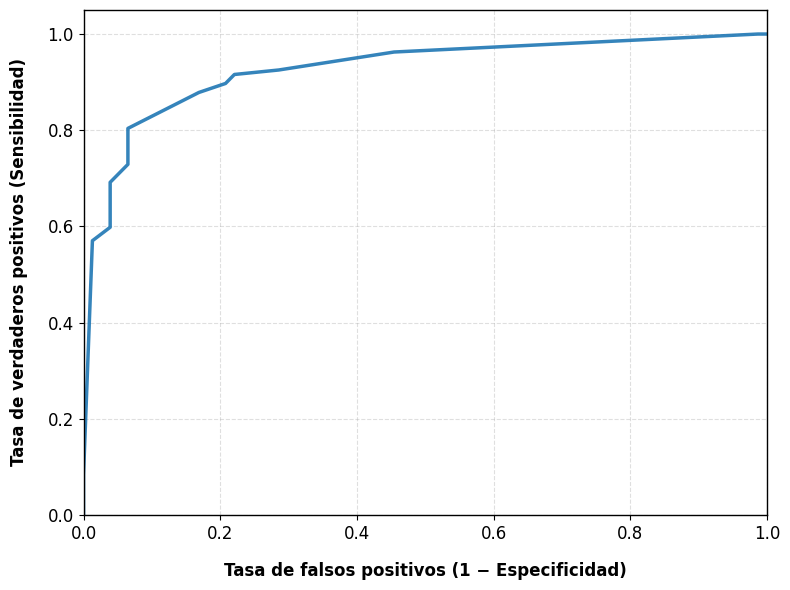

In [5]:
modelos_a_comparar = [
    ('Árbol de Decisión', pipeline_tree),
]
plot_roc_curves(modelos_a_comparar, X_test, y_test, spanish = True, tick_size = 12, show_legend = False, label_pad = 14)

La trayectoria de la curva ROC, con un AUC de $0.926$, ratifica que el **Árbol de Decisión** ha capturado una frontera de decisión altamente eficiente que garantiza una separación clara entre las densidades de probabilidad de pacientes con y sin riesgo cardiovascular. La morfología escalonada de la gráfica refleja la naturaleza discreta de las reglas de partición en los nodos, demostrando que el modelo alcanza niveles óptimos de sensibilidad clínica sin requerir la complejidad de modelos de ensamble. Esta alta capacidad discriminativa legitima el uso del umbral estándar de $0.5$, ya que la curva se sitúa en una zona de alta fidelidad donde el compromiso entre detectar casos positivos y evitar falsas alarmas es estable y resistente a pequeñas variaciones en los datos. En consecuencia, el rendimiento observado en la curva ROC asegura que el artefacto final sea lo suficientemente robusto para su despliegue operativo, proporcionando una base diagnóstica transparente y científicamente fundamentada.

# Matriz de Confusión y Análisis de Errores

Otro apartado indispensable en la evaluación del modelo es la matriz de confusión. A través de esta, se analiza la distribución de aciertos y errores del **Árbol de Decisión** en el conjunto de prueba, permitiendo cuantificar el impacto de los falsos negativos y falsos positivos. Este diagnóstico es crítico para validar la utilidad operativa del modelo en un escenario de triaje real, garantizando que el compromiso entre sensibilidad y precisión sea aceptable para la práctica médica antes de su despliegue definitivo.


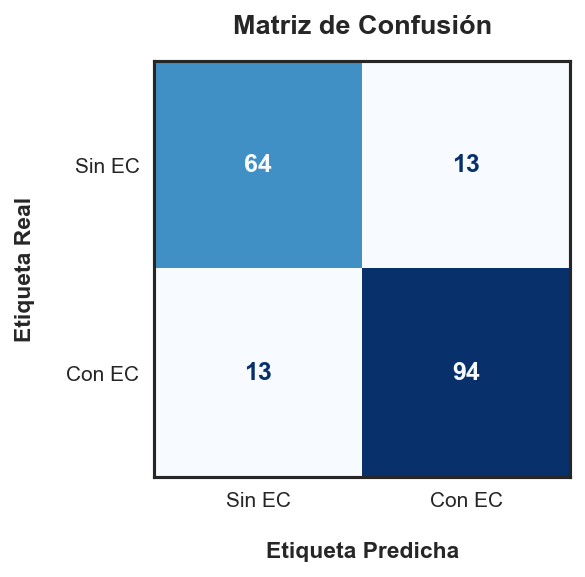

In [5]:
 plot_confusion_matrix(pipeline_tree, X_test, y_test, figsize = (4,4), label_size = 11, annot_size = 12, label_pad = 15)

Al observar los resultados, la matriz revela una simetría exacta en el error con $13$ falsos positivos y $13$ falsos negativos, lo que consolida una sensibilidad de $0.879$. Aunque estos $13$ casos de omisión diagnóstica podrían invitar a considerar arquitecturas de ensamble más potentes, la ganancia marginal que ofrecería un modelo como el Gradient Boosting no compensa la pérdida de transparencia ni el riesgo de una mayor varianza en el despliegue. El error observado se mantiene dentro de un margen de seguridad estadística que prioriza la generalización; al elegir este balance, se garantiza que el modelo no esté simplemente sobreajustando ruidos de la muestra, sino capturando patrones fisiológicos estables que permiten una toma de decisiones clínica predecible y auditable.

En última instancia, la presencia de estos errores residuales constituye la justificación técnica para una integración estrecha con el personal profesional. El objetivo de este desarrollo no es la creación de un modelo perfecto, sino de una herramienta aplicable a las dinámicas reales de los sistemas de salud, donde la rapidez de respuesta y la interpretabilidad son requisitos fundamentales. Al priorizar una arquitectura transparente, se garantiza que el algoritmo actúe como un sistema de apoyo al diagnóstico y no como una caja negra autónoma, permitiendo que el especialista aporte su juicio clínico precisamente en los casos de mayor ambigüedad. Esta sinergia asegura una implementación ética y viable, favoreciendo modelos rápidos e interpretables que funcionen en la práctica asistencial diaria por encima de una optimización teórica carente de contexto clínico.

# Análisis de Importancia

Para concluir la auditoría del modelo, se realiza un análisis de importancia por permutación que complementa de forma directa los hallazgos obtenidos mediante el *índice de información mutua* (MI) y mRMR durante la etapa de exploración de datos (EDA). Mientras que las técnicas de selección inicial identificaron la relevancia estadística intrínseca de los atributos, este análisis permite observar la importancia desde la perspectiva operativa del **Árbol de Decisión**, revelando cómo el algoritmo jerarquiza efectivamente la información para maximizar su capacidad predictiva. Al evaluar el impacto de cada variable en la degradación del desempeño del modelo, se asegura una interpretación coherente con la realidad clínica, validando que los pilares del diagnóstico coincidan con los indicadores fisiológicos de mayor peso evidenciable.


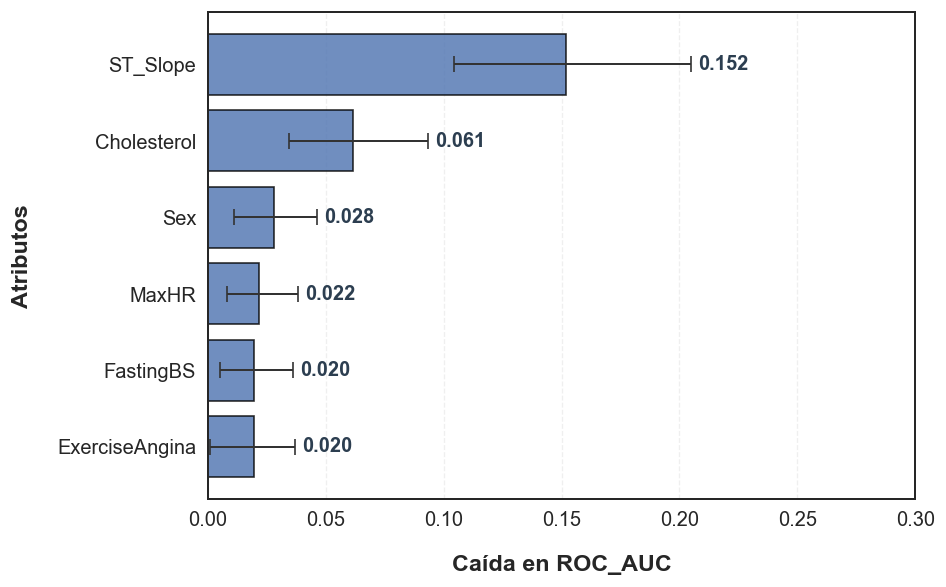

In [6]:
plot_permutation_importance(pipeline_tree, X_test, y_test,  xlim = (0, 0.3))

El análisis de importancia por permutación confirma que la arquitectura del modelo se fundamenta en la variable `ST_Slope`, cuya alteración provoca la mayor degradación en el ROC-AUC (~0.16), hallazgo que guarda una coherencia clínica estricta con la detección de isquemia miocárdica. Al contrastar estos resultados con *el índice de información mutua* (MI) del EDA, se observa una convergencia metodológica que revela cómo el algoritmo capitaliza la estructura jerárquica de los datos: mientras que el MI priorizó a `Oldpeak` ($0.123$), el árbol desplaza el protagonismo hacia la pendiente del segmento ST, utilizándola como pilar de ramificación primario y absorbiendo así parte de la varianza que el análisis estadístico previo atribuía a la depresión del segmento. Por otro lado, la consistencia de `Cholesterol` y `MaxHR` en ambos análisis los consolida como predictores universales de alta fidelidad, mientras que la contribución nula de atributos como `RestingBP` y `RestingECG` demuestra que el modelo ha logrado filtrar eficazmente el ruido estadístico. Esta sinergia entre la exploración inicial y la validación operativa asegura un pipeline parsimonioso y robusto, donde los pilares del diagnóstico coinciden plenamente con los marcadores fisiológicos de mayor peso en la evidencia médica.

:::{admonition} Nota Metodológica: Análisis de Importancia por Permutación
:class: note

Para evaluar de manera robusta la contribución de cada variable a la capacidad predictiva del modelo, se implementa el Análisis de Importancia por Permutación. A diferencia de las medidas intrínsecas (como la importancia de Gini), este método es agnóstico al modelo y evalúa la relevancia de los atributos directamente sobre el conjunto de prueba, evitando sesgos hacia variables de alta cardinalidad.

El procedimiento se fundamenta en la degradación del desempeño del modelo tras la ruptura de la relación entre una variable y el objetivo mediante permutaciones aleatorias. Si una variable es crítica, el error del modelo aumentará significativamente al "desordenar" sus valores. El puntaje de importancia $I_j$ para la variable $j$ se define como:

$$I_j = s_{orig} - \frac{1}{K} \sum_{k=1}^{K} s_{k,j}$$

Donde:

* $s_{orig}:$ Es el puntaje de la métrica de desempeño (en este caso, ROC-AUC) obtenido con el conjunto de datos original.

* $s_{k,j}:$ Es el puntaje obtenido tras permutar aleatoriamente los valores de la variable $j$ en la $k$-ésima repetición.

* $K:$ Representa el número de repeticiones (*bootstrap*) realizadas para estimar la variabilidad de la importancia.

Basado en el marco propuesto por [Fisher, Rudin y Dominici (2018)](https://doi.org/10.48550/arXiv.1801.01489), este enfoque permite identificar qué atributos son verdaderamente informativos para la generalización del modelo. Además, el cálculo de la desviación estándar sobre las $K$ repeticiones permite generar intervalos de confianza, asegurando que la jerarquía de predictores detectada sea estadísticamente estable y no un subproducto del ruido en la muestra de prueba.

:::

Finalmente, es crucial abordar por qué los modelos de clasificación lograron identificar fronteras de decisión claras pese a que el análisis de componentes principales (PCA) realizado en el EDA no mostró particiones evidentes. Esta discrepancia se explica por la limitación intrínseca del PCA estándar, el cual se restringe exclusivamente al espacio de las variables numéricas, ignorando la densa carga informativa codificada en los atributos categóricos. Al integrar variables determinantes como el tipo de dolor torácico o el sexo mediante un preprocesamiento adecuado, los modelos accedieron a dimensiones de varianza que el PCA omitió por diseño. Esta capacidad de los algoritmos para sintetizar información de naturaleza híbrida permitió capturar los patrones de riesgo cardiovascular que permanecían invisibles en una proyección simplificada de variables continuas, consolidando así la potencia del pipeline final.

# Serialización del Artefacto

Una vez validada la robustez técnica del **Árbol de Decisión** y confirmada su coherencia con la evidencia clínica, la fase final de esta libreta consiste en la *Serialización del Artefacto*. Este proceso trasciende el simple guardado de datos, pues se encarga de encapsular el `pipeline_tree` completo, el cual integra escaladores, codificadores y el propio estimador, en un archivo binario persistente mediante la librería `joblib`. El siguiente bloque de código gestiona de forma automatizada la jerarquía de archivos y detecta la raíz del proyecto para alojar el modelo directamente en el directorio `app/`. Esta disposición es crítica para cumplir con los requisitos de la arquitectura Docker, pues garantiza que el servicio de FastAPI encuentre el archivo `model.joblib` en la ruta exacta definida para el despliegue y asegura una transición fluida desde el entorno de experimentación hacia la puesta en producción.

In [5]:
import joblib
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
APP_DIR = PROJECT_ROOT / "app"
APP_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = APP_DIR / "model.joblib"
joblib.dump(pipeline_tree, MODEL_PATH);

Complementario a la serialización del artefacto, se integra un protocolo de monitoreo preventivo mediante la librería `Evidently`, enfocado en la detección de **Data Drift** (deriva de datos). En esta fase de pre-despliegue, el análisis se ejecuta como una validación interna de control, utilizando el conjunto de prueba (*X_test*) como un proxy de los datos de producción para compararlos contra la distribución de entrenamiento (*X_train*). Este procedimiento trasciende la simple evaluación de métricas de desempeño; su objetivo es confirmar que la partición aleatoria ha preservado la integridad estadística de las variables clínicas y establecer formalmente la línea base del proyecto. Al verificar que las distribuciones de variables críticas (como niveles de colesterol o presión arterial) se mantienen estables, garantizamos que el modelo no solo es preciso, sino que el ecosistema de MLOps está técnicamente capacitado para identificar desviaciones poblacionales o degradaciones en el rendimiento una vez que la API comience a procesar datos de pacientes en tiempo real.

:::{admonition} Video Demostrativo: Despliegue, Inferencia y Monitoreo
:class: note

La validación operativa de este sistema trasciende las métricas estáticas de evaluación. Como evidencia técnica de la viabilidad del flujo de trabajo continuo (MLOps), el siguiente material audiovisual documenta la integración del pipeline predictivo en un entorno de alta disponibilidad.

En la demostración se exponen tres fases críticas: la orquestación del servicio mediante Kubernetes, la ejecución de inferencias en tiempo real a través de la API REST (FastAPI) frente a perfiles clínicos aislados, y la supervisión preventiva del riesgo de *Data Drift* a través de la generación de reportes automatizados.

Para visualizar el despliegue de la infraestructura y la operación del sistema en tiempo real, **[haga clic aquí para acceder al video demostrativo (7 min)](https://uninorte-my.sharepoint.com/:v:/g/personal/cjarango_uninorte_edu_co/IQDV47ErLPFqRYgP1UkQqJ89AfD3IdsXDtxOX-wjAEUzaEs?nav=eyJyZWZlcnJhbEluZm8iOnsicmVmZXJyYWxBcHAiOiJPbmVEcml2ZUZvckJ1c2luZXNzIiwicmVmZXJyYWxBcHBQbGF0Zm9ybSI6IldlYiIsInJlZmVycmFsTW9kZSI6InZpZXciLCJyZWZlcnJhbFZpZXciOiJNeUZpbGVzTGlua0NvcHkifX0&e=SOrgGc)**.

:::